#### 1.对比1

In [ ]:
import glob
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import random
import time

# ==========================================
# 0. 全局配置
# ==========================================

# 图像大小设置 (宽, 高)
FIG_SIZE = (22, 10) 

# 是否显示箱内的散点
SHOW_INNER_DOTS = False
# SHOW_INNER_DOTS = True

# 是否绘制 Q-Error 图
SHOW_Q_ERROR_PLOT = False

# --- [关键修改] 随机种子设置 ---
RANDOM_SEED = 62225 
# RANDOM_SEED = None 

# 采样设置 (None 为使用全部)
SAMPLE_SIZE = 20

# 方法显示的顺序 (不在列表中的将被过滤掉)
METHOD_ORDER = [
    # 'baseline_graph_only', 
    'UN', 
    'PO', 
    'MAB', 
    'FOIS_nrs', 
    'FOIS_rs', 
    'POSS', 
] 

# METHOD_ORDER = [
#     'baseline_graph_only', 
#     'baseline_uniform', 
#     'baseline_proxy', 
#     'baseline_proxy_a', 
#     'baseline_proxy_a_unbiased_test1', 
#     'proxyE_importance', 
# ] 

# 箱型图颜色主题
BOX_PALETTE = "Set3"

# ==========================================
# 1. 种子应用逻辑
# ==========================================
if RANDOM_SEED is not None:
    print(f"[CONFIG] 检测到固定随机种子: {RANDOM_SEED} -> 采样结果将固定不变。")
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED) 
else:
    print(f"[CONFIG] 随机种子为 None -> 每次采样结果将不同。")

# ==========================================
# 2. 定义核心计算与绘图函数
# ==========================================

def calculate_log_signed_q_error(row):
    """
    计算基于 Log2 的 Signed Q-Error
    """
    t = max(1.0, row['T_true']) 
    e = max(1.0, row['T_hat'])
    
    if e >= t:
        return np.log2(e / t)
    else:
        return -np.log2(t / e)

def load_data_from_dir(result_summarys_dir: str, dataset_name: str, proxy_model: str, sample_n: int = None) -> pd.DataFrame:
    """
    读取数据
    """
    pattern = os.path.join(result_summarys_dir, "results_summary_run_*.csv")
    all_files = glob.glob(pattern)
    
    if not all_files:
        return pd.DataFrame()

    # --- 随机采样 ---
    total_files = len(all_files)
    if sample_n and total_files > sample_n:
        selected_files = random.sample(all_files, sample_n)
        print(f"   [Sampling] 发现 {total_files} 个文件，随机采样 {sample_n} 个参与统计。")
    else:
        selected_files = all_files
        print(f"   [All Data] 发现 {total_files} 个文件，全部使用。")

    df_list = []
    for f in selected_files:
        try:
            tmp = pd.read_csv(f)
            
            # --- 提取查询名称 ---
            if 'query_basename' in tmp.columns:
                tmp['query_identifier'] = tmp['query_basename'].astype(str).apply(
                    lambda x: x.replace('.graph', '')
                )
            elif 'query_index' in tmp.columns:
                tmp['query_identifier'] = "idx_" + tmp['query_index'].astype(str)
            else:
                tmp['query_identifier'] = os.path.basename(f) + "_row" + tmp.index.astype(str)
            
            if 'T_true' not in tmp.columns or 'T_hat' not in tmp.columns:
                continue

            df_list.append(tmp)
        except Exception as e:
            print(f"[WARN] 读取文件 {f} 失败: {e}")
    
    if not df_list:
        return pd.DataFrame()

    df = pd.concat(df_list, ignore_index=True)

    # 1. 计算 Signed Relative Error
    df["signed_relative_error"] = np.where(
        df["T_true"] != 0, 
        (df["T_hat"] - df["T_true"]) / df["T_true"],
        np.nan
    )

    # 2. 计算 Log Signed Q-Error
    df["log_signed_q_error"] = df.apply(calculate_log_signed_q_error, axis=1)
    
    # 3. 标记高估还是低估
    df["est_type"] = np.where(df["T_hat"] >= df["T_true"], "Over", "Under")

    df["proxy_model"] = proxy_model
    df["dataset_name"] = dataset_name
    
    return df.dropna(subset=["signed_relative_error", "log_signed_q_error"])

def analyze_and_print_outliers(df, metric_col, method_col="method", id_col="query_identifier"):
    """
    计算并打印异常值详情
    """
    print(f"\n{'='*20} 异常值分析: {metric_col} {'='*20}")
    
    existing_methods = set(df[method_col].unique())
    
    # [修改] 严格根据 METHOD_ORDER 筛选分析对象
    if METHOD_ORDER:
        # 只保留既在 METHOD_ORDER 中，又存在于数据中的方法
        methods_to_analyze = [m for m in METHOD_ORDER if m in existing_methods]
        # 注意：这里删除了之前 extend(remain) 的逻辑
    else:
        methods_to_analyze = sorted(list(existing_methods))

    for method in methods_to_analyze:
        subset = df[df[method_col] == method]
        if subset.empty: continue
        
        Q1 = subset[metric_col].quantile(0.25)
        Q3 = subset[metric_col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = subset[(subset[metric_col] < lower_bound) | (subset[metric_col] > upper_bound)].copy()
        
        if not outliers.empty:
            outliers['abs_err'] = outliers[metric_col].abs()
            outliers = outliers.sort_values(by='abs_err', ascending=False)
            
            print(f"\n[Method: {method}] 检测到 {len(outliers)} 个奇异值 (Bounds: [{lower_bound:.4f}, {upper_bound:.4f}]):")
            
            top_n = outliers.head(15)
            for idx, row in top_n.iterrows():
                print(f"  - Query: {str(row[id_col]):<40} | Val: {row[metric_col]:.4f}")
                
            if len(outliers) > 15:
                print(f"  ... 还有 {len(outliers)-15} 个未显示")
        else:
            print(f"\n[Method: {method}] 无异常值。")
    print("="*60 + "\n")

def plot_dual_metrics_boxplot(df: pd.DataFrame, proxy_name: str, save_path: str = None):
    """
    绘制图表
    """
    if df.empty:
        return

    # [修改] 1. 绘图前先过滤数据：只保留 METHOD_ORDER 中的方法
    if METHOD_ORDER:
        # 过滤 DataFrame，仅保留 method 在 METHOD_ORDER 中的行
        df = df[df["method"].isin(METHOD_ORDER)].copy()
        
        if df.empty:
            print("[WARN] 过滤后数据为空，请检查 METHOD_ORDER 是否与数据中的 method 名称匹配。")
            return

    # 先分析异常值（此时 df 已经是过滤后的了）
    analyze_and_print_outliers(df, "signed_relative_error", id_col="query_identifier")

    # [修改] 2. 确定绘图顺序
    available_methods = set(df["method"].unique())
    
    if METHOD_ORDER:
        # 严格按照 METHOD_ORDER 排序，且只包含数据中存在的
        final_order = [m for m in METHOD_ORDER if m in available_methods]
    else:
        final_order = sorted(list(available_methods))

    sns.set_theme(style="whitegrid", font_scale=1.2)
    
    # --- 根据配置决定子图数量 ---
    if SHOW_Q_ERROR_PLOT:
        fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)
        ax1 = axes[0]
        ax2 = axes[1]
    else:
        fig, ax1 = plt.subplots(1, 1, figsize=FIG_SIZE)
        ax2 = None

    palette_dots = {"Over": "red", "Under": "blue"}
    
    # --- 核心辅助函数：只画须内部的点 ---
    def plot_inner_strips(ax, data, x_col, y_col, order_list):
        if not SHOW_INNER_DOTS:
            return

        # 只使用 final_order 中的方法
        current_methods = order_list 
        inner_data_list = []
        
        for m in current_methods:
            sub = data[data[x_col] == m]
            if sub.empty: continue
            
            Q1 = sub[y_col].quantile(0.25)
            Q3 = sub[y_col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            
            mask = (sub[y_col] >= lower) & (sub[y_col] <= upper)
            inner_data_list.append(sub[mask])
            
        if inner_data_list:
            inner_data = pd.concat(inner_data_list)
            sns.stripplot(
                data=inner_data, x=x_col, y=y_col, hue="est_type",
                palette=palette_dots, 
                order=order_list,
                jitter=0.25,  
                dodge=False,  
                alpha=0.6, size=4, ax=ax, legend=False 
            )

    # ==========================
    # 图1：Relative Error
    # ==========================
    sns.boxplot(
        data=df, x="method", y="signed_relative_error",
        hue="method", palette=BOX_PALETTE, dodge=False,
        order=final_order, # 使用过滤后的顺序
        showmeans=True, width=0.6,
        meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
        flierprops={"marker": "x", "color": "gray", "markeredgecolor": "gray", "markersize": 6}, 
        whis=1.5,
        ax=ax1
    )
    plot_inner_strips(ax1, df, "method", "signed_relative_error", final_order)
    
    ax1.axhline(0, color="green", linestyle="-", linewidth=2, label="Perfect (0.0)")
    ax1.axhline(0.1, color="gray", linestyle=":", linewidth=1)
    ax1.axhline(-0.1, color="gray", linestyle=":", linewidth=1)
    
    ax1.set_title(f"Signed Relative Error", fontsize=16, fontweight='bold')
    ax1.set_ylabel("Error Rate ((Est-True)/True)", fontsize=14)
    ax1.set_ylim(-1.0, 1.0) 
    ax1.tick_params(axis='x', rotation=30)
    if ax1.get_legend(): ax1.get_legend().remove()
    
    ax1.text(0.02, 0.98, f"Proxy: {proxy_name}", transform=ax1.transAxes, 
             fontsize=12, fontweight='bold', verticalalignment='top',
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))

    # ==========================
    # 图2：Log Signed Q-Error (按需)
    # ==========================
    if SHOW_Q_ERROR_PLOT and ax2 is not None:
        sns.boxplot(
            data=df, x="method", y="log_signed_q_error",
            hue="method", palette=BOX_PALETTE, dodge=False,
            order=final_order,
            showmeans=True, width=0.6,
            meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
            flierprops={"marker": "x", "color": "gray", "markeredgecolor": "gray", "markersize": 6},
            whis=1.5,
            ax=ax2
        )
        plot_inner_strips(ax2, df, "method", "log_signed_q_error", final_order)

        ax2.axhline(0, color="green", linestyle="-", linewidth=2, label="Perfect (1x)")
        for i in [1, 2, 3]:
            ax2.axhline(i, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
            ax2.axhline(-i, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
            
        ax2.set_title(f"Log2 Q-Error", fontsize=16, fontweight='bold')
        ax2.set_ylabel("Log2 Scale (Pos: Over, Neg: Under)\n1.0=2x, 2.0=4x, 3.0=8x", fontsize=14)
        ax2.set_ylim(-6, 6)
        ax2.yaxis.set_major_locator(ticker.MultipleLocator(1))
        ax2.tick_params(axis='x', rotation=30)
        if ax2.get_legend(): ax2.get_legend().remove()
        
        ax2.text(0.02, 0.98, f"Proxy: {proxy_name}", transform=ax2.transAxes, 
                 fontsize=12, fontweight='bold', verticalalignment='top',
                 bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))

    # 图例
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='x', color='gray', linestyle='None', markersize=8, label='Outlier')]
    if SHOW_INNER_DOTS:
        legend_elements.insert(0, Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Under (Inner)'))
        legend_elements.insert(0, Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Over (Inner)'))
    
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98))

    fig.suptitle(f"Accuracy Metrics Analysis", fontsize=20, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95]) 
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"[INFO] 图表已保存至: {save_path}")
    
    plt.show()
    plt.close()

# ==========================================
# 2. 配置与执行
# ==========================================
# dataset_name = "dataset_one" 
dataset_name = "dataset_three3" 
output_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results"

# 采样设置

proxy_models = [
    # 'ML1_proxy4b_probability',
    # 'ML1_proxy2b_probability_ML2_proxy1_probability',
    'ML1_proxy4b_probability_ML2_proxy1_probability',
    # 'ML1_proxy4b_probability',
    # 'Dist_Beta_U_proxy2',
    # 'Dist_Asym_LeftHigh_proxy2',
    # 'Dist_Asym_RightHigh_proxy2',

    
    # # # 'Dist_Bimodal_proxy2',
    # 'Dist_Bimodal_left_proxy2',
    # 'Dist_Bimodal_right_proxy2',

    # 'Dist_SkewHigh_proxy2',
    # 'Dist_SkewLow_proxy2',

    # 'Dist_Extreme_Mix_proxy2',

]
print(f"[INFO] 图像尺寸: {FIG_SIZE}")
print(f"[INFO] 是否绘制 Q-Error 图: {SHOW_Q_ERROR_PLOT}")
print(f"[INFO] 随机种子: {RANDOM_SEED}")

for proxy in proxy_models:
    summarys_dir = os.path.join(output_dir, f"result_summarys/{proxy}")
    
    df_proxy = load_data_from_dir(summarys_dir, dataset_name, proxy, sample_n=SAMPLE_SIZE)
    
    if not df_proxy.empty:
        print(f"\n>>> 正在处理 Proxy: {proxy} (记录数: {len(df_proxy)})")
        
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        # 不同的种子或不同的采样，结合时间戳，文件不会冲突，且可追溯
        save_path = os.path.join(summarys_dir, f"{dataset_name}_metrics_analysis_{timestamp}.png")
        
        plot_dual_metrics_boxplot(df_proxy, proxy_name=proxy, save_path=save_path)
    else:
        print(f"[WARN] 跳过 {proxy} (无数据)")

#### 2. 对比2

正在从目录中随机抽取 10 个 Baseline 文件...
已选中 Baseline 文件: ['results_summary_run_20.csv', 'results_summary_run_2.csv', 'results_summary_run_13.csv', 'results_summary_run_6.csv', 'results_summary_run_7.csv', 'results_summary_run_4.csv', 'results_summary_run_8.csv', 'results_summary_run_3.csv', 'results_summary_run_9.csv', 'results_summary_run_10.csv']
Baseline 数据加载完成，共 50880 行。
正在读取 FaSTestO: /home/wangshuo/resource/datasets/parler_data/dataset_three/results/results_summary_FaSTestO.csv
正在标准化 query_basename...
FaSTestO   查询数: 246
Baseline   查询数 (Unique): 246
==> 最终交集查询数: 246
最大绝对相对误差 (Max ARE): 4.04


/tmp/ipykernel_1721163/4224581954.py:208: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="method", y="SymRE", data=df_all, order=plot_order,


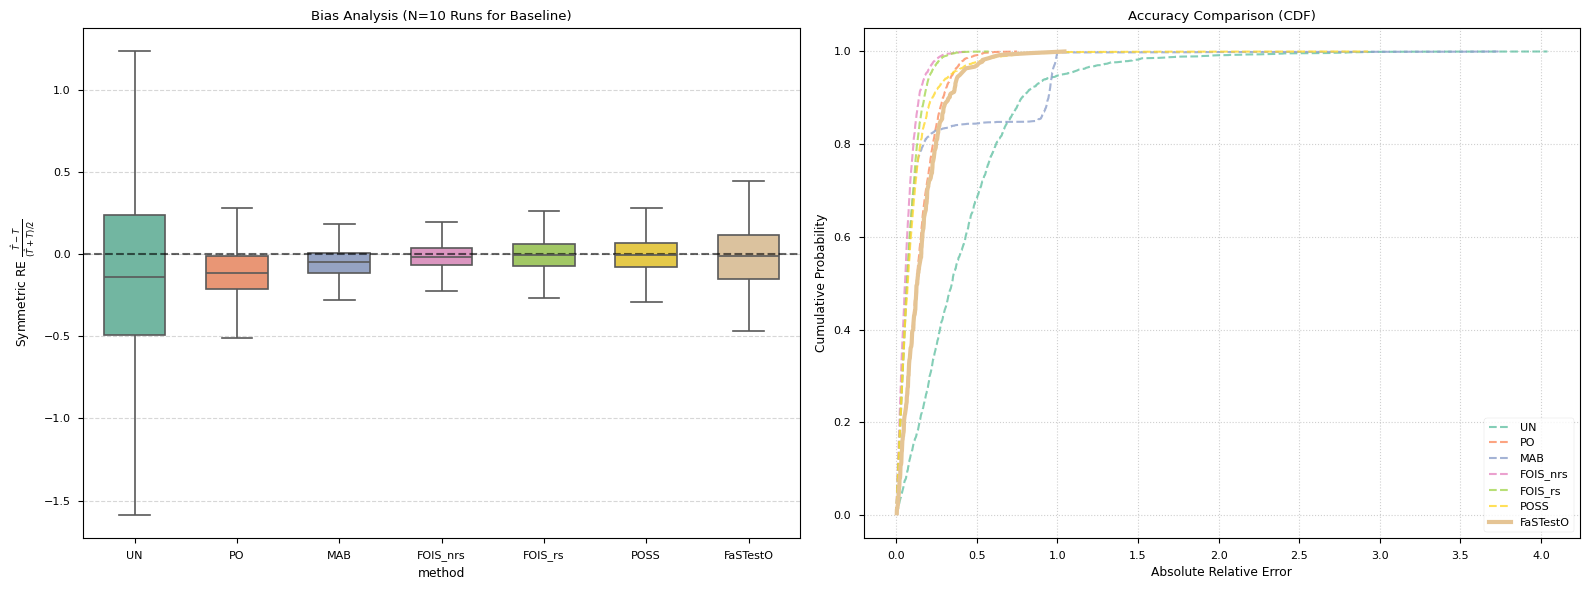

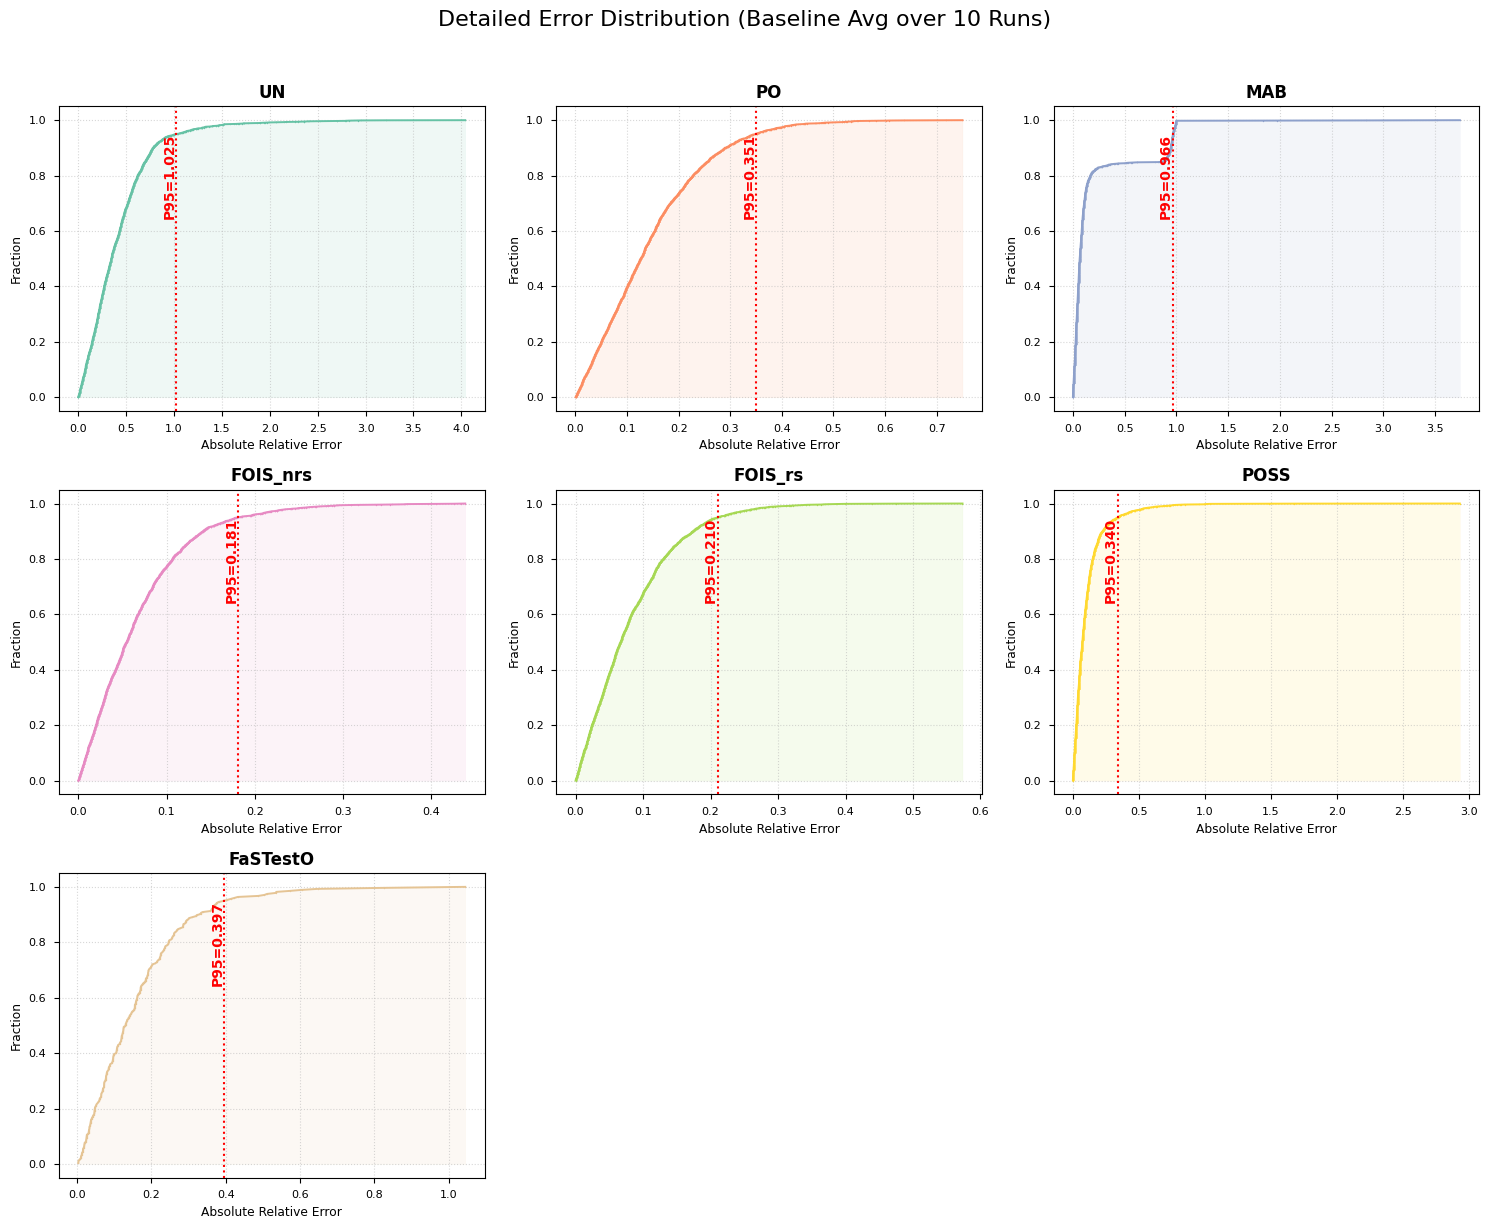


       AQP Evaluation Metrics Summary
Method               | Mean       | Median     | P95        | Max       
----------------------------------------------------------------------
UN                   |  41.96%    |  34.53%    | 102.47%    | 404.07%
PO                   |  14.54%    |  12.62%    |  35.08%    |  75.01%
MAB                  |  20.79%    |   6.61%    |  96.63%    | 373.72%
FOIS_nrs             |   6.85%    |   5.47%    |  18.14%    |  43.83%
FOIS_rs              |   8.26%    |   6.68%    |  21.04%    |  57.33%
POSS                 |  10.79%    |   7.20%    |  34.01%    | 292.84%
FaSTestO             |  16.23%    |  13.10%    |  39.68%    | 104.39%
----------------------------------------------------------------------


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import math
import random

# ==========================================
# 1. 配置路径与采样设置
# ==========================================
# Distribution = 'ML1_proxy4b_probability_ML2_proxy1_probability'
Distribution = 'ML1_proxy4b_probability'
dataset = 'dataset_three'
fatestO_file = 'results_summary_FaSTestO.csv'

# --- [用户配置区] 是否启用对比 ---
# ENABLE_WANDERJOIN = True   # 是否包含 WanderJoin 结果
ENABLE_WANDERJOIN = False   # 是否包含 WanderJoin 结果
ENABLE_FASTESTO = False     # 是否包含 FaSTestO 结果
SHOW_ALL_POINTS = False    
SHOW_OUTLIERS = False  
# --- 采样设置 ---
N_SAMPLES = 10  # 随机选取多少个 Baseline run 文件参与计算

# --- 路径配置 ---
path_wj = f"/home/wangshuo/projects/Neo4j_Exp/pythonProject/src/baseline/wanderjoin_multi_{dataset}.csv"
path_fastesto = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/{fatestO_file}"
baseline_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/result_summarys/{Distribution}/"

# 方法定义
methods_wj = ['WJ_uniform_multi', 'WJ_importance_multi']
methods_baseline = ['FOIS_nrs', 'FOIS_rs', 'POSS','UN','PO','MAB']
final_order = ['WJU', 'WJP', 'UN','PO','MAB', 'FOIS_nrs', 'FOIS_rs', 'POSS', 'FaSTestO']

# ==========================================
# 2. 数据加载与预处理
# ==========================================

# --- 2.1 加载 Baseline (必须存在) ---
if not os.path.exists(baseline_dir):
    print(f"[Error] Baseline 目录不存在: {baseline_dir}")
    exit()

print(f"正在从目录中随机抽取 {N_SAMPLES} 个 Baseline 文件...")
all_files = [f for f in os.listdir(baseline_dir) if f.startswith("results_summary_run_") and f.endswith(".csv")]

if len(all_files) == 0:
    print("[Error] Baseline 目录下没有找到 results_summary_run_*.csv 文件")
    exit()

if len(all_files) < N_SAMPLES:
    print(f"[Warning] 目录下只有 {len(all_files)} 个文件，少于要求的 {N_SAMPLES}，将全部使用。")
    selected_files = all_files
else:
    selected_files = random.sample(all_files, N_SAMPLES)
print(f"已选中 Baseline 文件: {selected_files}")

df_base_list = []
for f in selected_files:
    path = os.path.join(baseline_dir, f)
    try:
        temp_df = pd.read_csv(path)
        df_base_list.append(temp_df)
    except Exception as e:
        print(f"读取文件 {f} 失败: {e}")

if not df_base_list:
    print("[Error] 无法读取任何 Baseline 文件，程序终止。")
    exit()

df_base_raw = pd.concat(df_base_list, ignore_index=True)
print(f"Baseline 数据加载完成，共 {len(df_base_raw)} 行。")

# --- 2.2 加载 WanderJoin (可选) ---
df_wj_raw = None
if ENABLE_WANDERJOIN:
    if os.path.exists(path_wj):
        print(f"正在读取 WanderJoin: {path_wj}")
        df_wj_raw = pd.read_csv(path_wj)
    else:
        print(f"[Warning] 启用 WanderJoin 但文件不存在，跳过: {path_wj}")

# --- 2.3 加载 FaSTestO (可选) ---
df_fast_raw = None
if ENABLE_FASTESTO:
    if os.path.exists(path_fastesto):
        print(f"正在读取 FaSTestO: {path_fastesto}")
        df_fast_raw = pd.read_csv(path_fastesto)
    else:
        print(f"[Warning] 启用 FaSTestO 但文件不存在，跳过: {path_fastesto}")

# -----------------------------------------------------------
# 标准化文件名 (去除 .graph 后缀)
# -----------------------------------------------------------
print("正在标准化 query_basename...")

# 定义一个帮助函数来处理
def standardize_name(df):
    if df is not None and 'query_basename' in df.columns:
        df['query_basename'] = df['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)
    return df

df_base_raw = standardize_name(df_base_raw)
df_wj_raw = standardize_name(df_wj_raw)
df_fast_raw = standardize_name(df_fast_raw)

# -----------------------------------------------------------
# 动态提取交集 (Dynamic Intersection)
# -----------------------------------------------------------
# 基础集合：Baseline 的查询
common_queries = set(df_base_raw['query_basename'].unique())

if df_wj_raw is not None:
    qs_wj = set(df_wj_raw['query_basename'].unique())
    common_queries = common_queries.intersection(qs_wj)
    print(f"WanderJoin 查询数: {len(qs_wj)}")

if df_fast_raw is not None:
    qs_fast = set(df_fast_raw['query_basename'].unique())
    common_queries = common_queries.intersection(qs_fast)
    print(f"FaSTestO   查询数: {len(qs_fast)}")

print(f"Baseline   查询数 (Unique): {len(df_base_raw['query_basename'].unique())}")
print(f"==> 最终交集查询数: {len(common_queries)}")

if len(common_queries) == 0:
    print("[Error] 交集为空，无法进行对比！")
else:
    # -----------------------------------------------------------
    # 数据过滤与合并
    # -----------------------------------------------------------
    df_combined_list = []

    # 1. 处理 Baseline
    df_base = df_base_raw[df_base_raw['query_basename'].isin(common_queries)].copy()
    df_base = df_base[df_base['method'].isin(methods_baseline)].copy()
    
    # 建立 GT 映射 (从 Baseline 获取)
    truth_map = df_base[['query_basename', 'T_true']]\
        .drop_duplicates(subset=['query_basename'])\
        .set_index('query_basename')['T_true']\
        .to_dict()
    
    # 过滤有效的 GT
    valid_queries = {q for q, t in truth_map.items() if t > 0 and not pd.isna(t)}
    
    # 重新过滤 Baseline 并加入列表
    df_base = df_base[df_base['query_basename'].isin(valid_queries)].copy()
    df_base['T_true'] = df_base['query_basename'].map(truth_map)
    df_combined_list.append(df_base[['method', 'T_hat', 'T_true']])

    # 2. 处理 WanderJoin (如果存在)
    if df_wj_raw is not None:
        df_wj = df_wj_raw[df_wj_raw['query_basename'].isin(valid_queries)].copy()
        df_wj = df_wj[df_wj['method'].isin(methods_wj)].copy()
        # 改名
        df_wj['method'] = df_wj['method'].replace({
            'WJ_uniform_multi': 'WJU', 
            'WJ_importance_multi': 'WJP'
        })
        df_wj['T_true'] = df_wj['query_basename'].map(truth_map)
        df_combined_list.append(df_wj[['method', 'T_hat', 'T_true']])

    # 3. 处理 FaSTestO (如果存在)
    if df_fast_raw is not None:
        df_fast = df_fast_raw[df_fast_raw['query_basename'].isin(valid_queries)].copy()
        df_fast['method'] = 'FaSTestO'
        df_fast['T_true'] = df_fast['query_basename'].map(truth_map)
        df_combined_list.append(df_fast[['method', 'T_hat', 'T_true']])

    # 合并
    df_all = pd.concat(df_combined_list, ignore_index=True)

    # ==========================================
    # 3. 计算误差
    # ==========================================
    epsilon = 1e-9 
    df_all['SymRE'] = (df_all['T_hat'] - df_all['T_true']) / (0.5 * (df_all['T_hat'] + df_all['T_true']) + epsilon)
    df_all['ARE'] = (df_all['T_hat'] - df_all['T_true']).abs() / (df_all['T_true'] + epsilon)

    max_are = df_all['ARE'].max()
    USE_LOG_SCALE = max_are > 5.0 
    print(f"最大绝对相对误差 (Max ARE): {max_are:.2f}")

    if USE_LOG_SCALE:
        df_all['PlotValue'] = np.maximum(df_all['ARE'], 1e-4)
        x_label_cdf = "Absolute Relative Error (Log Scale)"
    else:
        df_all['PlotValue'] = df_all['ARE']
        x_label_cdf = "Absolute Relative Error"

    # 动态生成绘图顺序 (只包含实际存在的方法)
    plot_order = [m for m in final_order if m in df_all['method'].unique()]
    
    # 颜色配置
    colors = sns.color_palette("Set2", n_colors=len(plot_order))
    method_colors = dict(zip(plot_order, colors))

    # ==========================================
    # 4. 绘图 Part 1: Bias + CDF
    # ==========================================    

    plt.style.use('seaborn-v0_8-paper')
    fig1, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Boxplot
    sns.boxplot(x="method", y="SymRE", data=df_all, order=plot_order,
                ax=axes[0], palette=method_colors, 
                showfliers=SHOW_OUTLIERS, width=0.6, linewidth=1.2)
    
    if SHOW_ALL_POINTS:
        df_all['EstimationType'] = df_all['SymRE'].apply(lambda x: 'High' if x >= 0 else 'Low')
        sns.stripplot(x="method", y="SymRE", data=df_all, order=plot_order,
                      ax=axes[0], hue="EstimationType", 
                      palette={'High': 'red', 'Low': 'blue'},
                      size=2.0, alpha=0.3, jitter=True, dodge=False, legend=False)

    axes[0].axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
    axes[0].set_title(f"Bias Analysis (N={N_SAMPLES} Runs for Baseline)")
    axes[0].set_ylabel(r"Symmetric RE $\frac{\hat{T} - T}{(\hat{T} + T)/2}$")
    axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

    # CDF
    for method in plot_order:
        subset = df_all[df_all['method'] == method]['PlotValue'].sort_values()
        if subset.empty: continue
        y_vals = np.arange(1, len(subset) + 1) / len(subset)
        
        lw = 3.0 if method == 'FaSTestO' else 1.5
        ls = '-' if method == 'FaSTestO' else '--'
        alpha = 1.0 if method == 'FaSTestO' else 0.8
        
        axes[1].plot(subset, y_vals, label=method, color=method_colors[method], 
                     linewidth=lw, linestyle=ls, alpha=alpha)

    axes[1].set_title("Accuracy Comparison (CDF)")
    axes[1].set_xlabel(x_label_cdf)
    axes[1].set_ylabel("Cumulative Probability")
    axes[1].legend(loc='lower right')
    axes[1].grid(True, which="both", linestyle=':', alpha=0.6)
    if USE_LOG_SCALE: axes[1].set_xscale('log')
    plt.tight_layout()
    plt.show()

    # ==========================================
    # 5. 绘图 Part 2: Detailed Subplots
    # ==========================================
    cols = min(len(plot_order), 3)
    if cols > 0:
        rows = math.ceil(len(plot_order) / cols)    
        fig2 = plt.figure(figsize=(5 * cols, 4 * rows))
        fig2.suptitle(f"Detailed Error Distribution (Baseline Avg over {N_SAMPLES} Runs)", fontsize=16, y=1.02)
        target_percentiles = [0.95] 

        for idx, method in enumerate(plot_order):
            ax = plt.subplot(rows, cols, idx + 1)
            subset = df_all[df_all['method'] == method]['PlotValue'].sort_values()
            if subset.empty: continue
            
            y_vals = np.arange(1, len(subset) + 1) / len(subset)
            color = method_colors[method]
            
            ax.plot(subset, y_vals, marker='.', markersize=2, linestyle='-', color=color)
            ax.fill_between(subset, y_vals, color=color, alpha=0.1)
            
            for p in target_percentiles:
                p_val = subset.quantile(p)
                ax.axvline(p_val, color='red', linestyle=':', linewidth=1.5)
                ax.text(p_val, p, f"P{int(p*100)}={p_val:.3f}", 
                        rotation=90, color='red', fontsize=10, fontweight='bold',
                        verticalalignment='top', horizontalalignment='right')

            ax.set_title(f"{method}", fontsize=12, fontweight='bold')
            ax.set_xlabel(x_label_cdf)
            ax.set_ylabel("Fraction")
            ax.grid(True, which="both", linestyle=':', alpha=0.5)
            if USE_LOG_SCALE: ax.set_xscale('log')

        plt.tight_layout()
        plt.show()

    # ==========================================
    # 6. 表格输出
    # ==========================================
    print("\n" + "="*50)
    print("       AQP Evaluation Metrics Summary")
    print("="*50)
    
    summary_table = df_all.groupby('method')['ARE'].agg(
        Mean_ARE='mean', Median_ARE='median',
        P95_ARE=lambda x: x.quantile(0.95), Max_ARE='max'
    )
    existing_methods = [m for m in final_order if m in summary_table.index]
    summary_table = summary_table.loc[existing_methods]
    
    print(f"{'Method':<20} | {'Mean':<10} | {'Median':<10} | {'P95':<10} | {'Max':<10}")
    print("-" * 70)
    for method in existing_methods:
        row = summary_table.loc[method]
        print(f"{method:<20} | {row['Mean_ARE']*100:6.2f}%    | {row['Median_ARE']*100:6.2f}%    | {row['P95_ARE']*100:6.2f}%    | {row['Max_ARE']*100:6.2f}%")
    print("-" * 70)